In [96]:
import numpy as np

from vulture.main import get_denoiser, transform_image
from vulture.models.external.vit_wrapper import PretrainedViTWrapper, MODEL_MAP
from vulture.utils import to_numpy, do_2D_pca

import torch
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from PIL import Image
import matplotlib.pyplot as plt

from typing import Literal

In [97]:
device = 'cuda:0'

dv2_model = PretrainedViTWrapper(MODEL_MAP["LOFTUP_FULL"], add_flash_attn=False, device=device)
dv2_model_no_pe = PretrainedViTWrapper(MODEL_MAP["LOFTUP_FULL"], add_flash_attn=False, device=device)
dv2_model_no_pe.model.pos_embed = torch.nn.Parameter(torch.ones_like(dv2_model_no_pe.model.pos_embed))
denoiser = get_denoiser('../trained_models/dvt.pth', device, True, False)

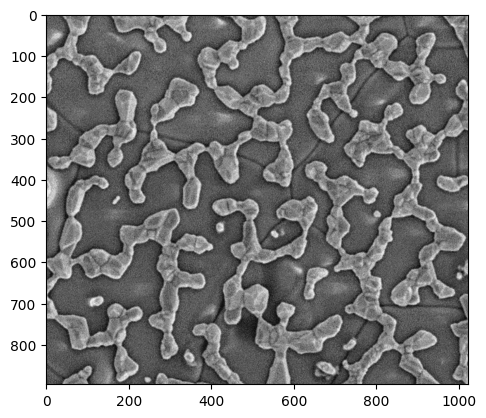

In [98]:
# img = Image.open('../images/black_square_518.png').convert('RGB')
# img = Image.open('../data/natural/bulldog_518.png').convert('RGB')
# img = img.rotate(90, expand=True)
# img = Image.open('../data/sofc/default_image_518.png').convert('RGB')
# img = Image.open('../images/black_square_518.png').convert('RGB')
img = Image.open('../images/default_image.jpg').convert('RGB')

img_tensor, _ = transform_image(img, device, False)

plt.imshow(img)

In [99]:
# sl = np.s_[362:363, :, :]
sl = np.s_[:, :, :]

feats_orig = dv2_model.forward_features(img_tensor, make_2D=True)
feats_orig_np = to_numpy(feats_orig)[sl]
# print(feats_orig_np.shape)

feats_no_pe = dv2_model_no_pe.forward_features(img_tensor, make_2D=True)
feats_no_pe_np = to_numpy(feats_no_pe)[sl]

to_remove_channels = [47, 113, 117, 359]
feats_channel_blanked = feats_orig.detach().clone()
feats_channel_blanked[:, to_remove_channels, :, :] = 0
feats_channel_blanked_np = to_numpy(feats_channel_blanked)[sl]

feats_denoised = denoiser.forward_(feats_orig)
feats_denoised_np = to_numpy(feats_denoised)[sl]

In [100]:
def get_ramp(dir: Literal['lr', 'ud', 'diag', 'radial']) -> np.ndarray:
    """Generate a ramp mask in the specified direction."""
    if dir == 'lr':
        return np.tile(np.linspace(0, 1, w), (h, 1))
    elif dir == 'ud':
        return np.tile(np.linspace(0, 1, h), (w, 1)).T
    elif dir == 'diag':
        return np.linspace(1, 0, max(h, w))[:h, None] + np.linspace(0, 1, max(h, w))[:w]
    elif dir == 'radial':
        yy, xx = np.meshgrid(np.arange(h), np.arange(w), indexing='ij')
        cy, cx = h // 2, w // 2
        r = np.sqrt((yy - cy) ** 2 + (xx - cx) ** 2)
        r_norm = r / r.max()
        return  1 - r_norm
    else:
        raise ValueError("Direction must be 'lr', 'ud', or 'diag'.")


def gen_sample_mask(shape: tuple[int, int], step: int = 4, cutoff_frac: float=1.0) -> np.ndarray:
    """Generate a sampling mask for an array, taking every `step`-th element."""
    cutoff_y, cutoff_x = int(shape[0] * cutoff_frac), int(shape[1] * cutoff_frac)
    mask = np.zeros(shape, dtype=bool)
    mask[0:cutoff_y:step, 0:cutoff_x:step] = True
    return mask

In [101]:
def linear_probe(feats: np.ndarray, target: np.ndarray, sample_mask: np.ndarray) -> tuple[np.ndarray, float]:
    """Train a linear regression model on sampled features to predict the target."""
    c, h, w = feats.shape
    X = feats[:, sample_mask].T  # Shape: (num_samples, c)
    y = target[sample_mask]       # Shape: (num_samples,)

    model = LinearRegression()
    model.fit(X, y)

    # Predict on all features
    X_full = feats.reshape(c, -1).T  # Shape: (h*w, c)
    y_pred = model.predict(X_full)    # Shape: (h*w,)

    score = model.score(X_full, target.flatten())  # R^2 score on training data
    return y_pred.reshape(h, w), float(score)

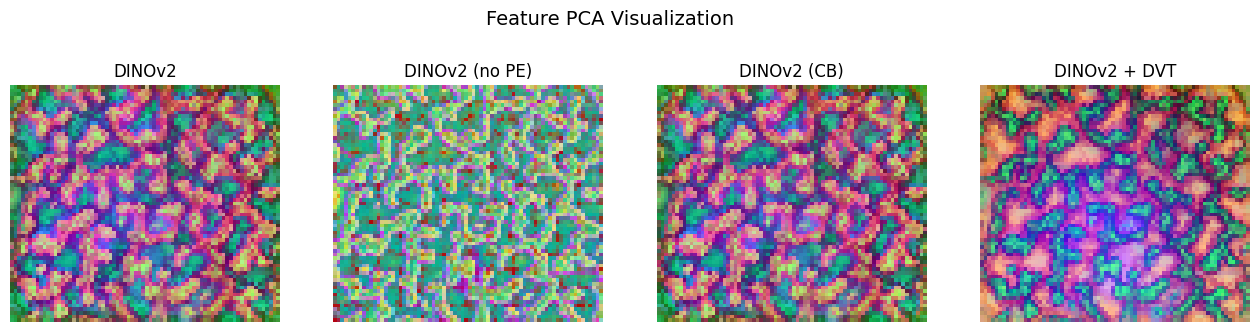

In [107]:
N_COLS = 4
WIDTH = 4
fig, axs = plt.subplots(1, N_COLS, figsize=(WIDTH * N_COLS, WIDTH))

titles = ['DINOv2', 'DINOv2 (no PE)', 'DINOv2 (CB)', 'DINOv2 + DVT']
fig.suptitle('Feature PCA Visualization', fontsize=14)
for arr, ax, title in zip((feats_orig_np, feats_no_pe_np, feats_channel_blanked_np, feats_denoised_np), axs, titles):
    ax.imshow(do_2D_pca(arr, pre_norm='minmax', post_norm='minmax', n_components=min(arr.shape[0], 3)))
    ax.axis('off')
    ax.set_title(title)

In [103]:
c, h, w = feats_denoised_np.shape
sample_mask = gen_sample_mask((h, w), step=6, cutoff_frac=0.8)
ramp = get_ramp('ud')

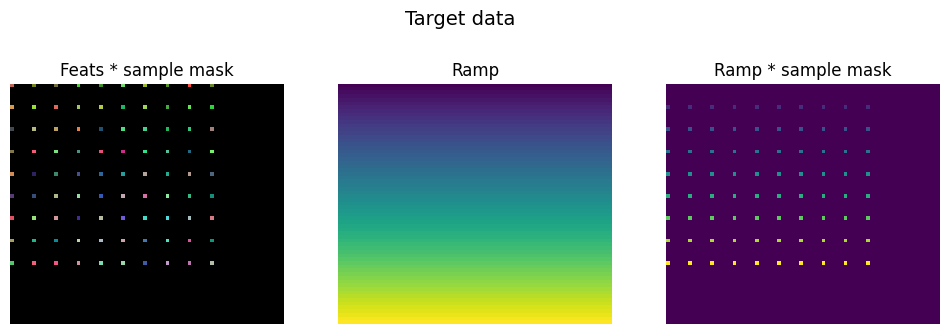

In [104]:
N_COLS = 3
fig, axs = plt.subplots(1, N_COLS, figsize=(WIDTH * N_COLS, WIDTH))

titles = ['Feats * sample mask', 'Ramp', 'Ramp * sample mask']
fig.suptitle('Target data', fontsize=14)

masked_feats = do_2D_pca(feats_denoised_np , post_norm='minmax') * np.expand_dims(sample_mask, -1)
for arr, ax, title in zip((masked_feats, ramp, ramp * sample_mask), axs, titles):
    ax.imshow(arr)
    ax.axis('off')
    ax.set_title(title)

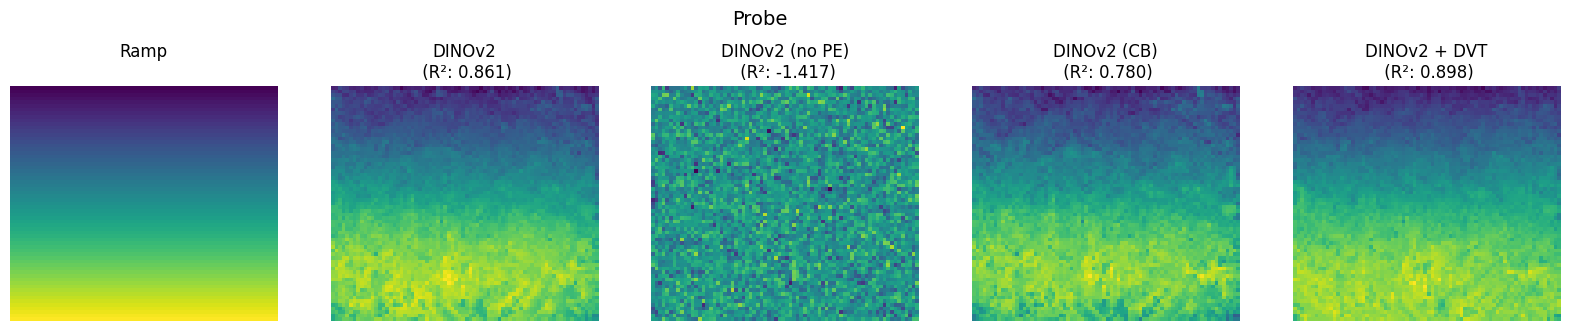

In [105]:
N_COLS = 5
fig, axs = plt.subplots(1, N_COLS, figsize=(WIDTH * N_COLS, WIDTH))

titles = ['Ramp', 'DINOv2', 'DINOv2 (no PE)', 'DINOv2 (CB)', 'DINOv2 + DVT']
fig.suptitle('Probe', fontsize=14)

for arr, ax, title in zip((ramp, feats_orig_np, feats_no_pe_np, feats_channel_blanked_np, feats_denoised_np), axs, titles):
    if title != 'Ramp':
        res, score = linear_probe(arr, ramp, sample_mask)
        title += f'\n (R²: {score:.3f})'
    else:
        res = arr
        title += f'\n'
    ax.imshow(res)
    ax.axis('off')
    ax.set_title(title)